# Démonstration de l'outil de diagnostic de la Malaria

Ce notebook utilise un modèle pré-entraîné pour simuler deux cas d'usage réels en milieu hospitalier : le diagnostic d'urgence d'une cellule isolée, et le tri automatique d'un lot de frottis sanguins.

## Imports 

In [1]:
import os
import sys
import random
import shutil
import matplotlib.pyplot as plt
from PIL import Image

sys.path.append(os.path.abspath(".."))
import Module.Application as app
import Module.MLP as mlp

PROJET_RACINE = os.path.abspath("..")
UNINFECTED_PATH = os.path.join(PROJET_RACINE, "Data", "Uninfected")
PARASITIZED_PATH = os.path.join(PROJET_RACINE, "Data", "Parasitized")

## Chargement du modèle

In [ ]:
MODELE_PATH = os.path.join(PROJET_RACINE, "Workflow", "modele_malaria.npz") 
w_l, b_l, m_l, s_l, p_comp, p_mean = mlp.load_model(MODELE_PATH)
print("Modèle chargé et prêt.")

✅ Modèle chargé et prêt.


## Cas d'usage 1 : Le Diagnostic d'Urgence

On soumet une cellule isolée inconnue à l'algorithme.

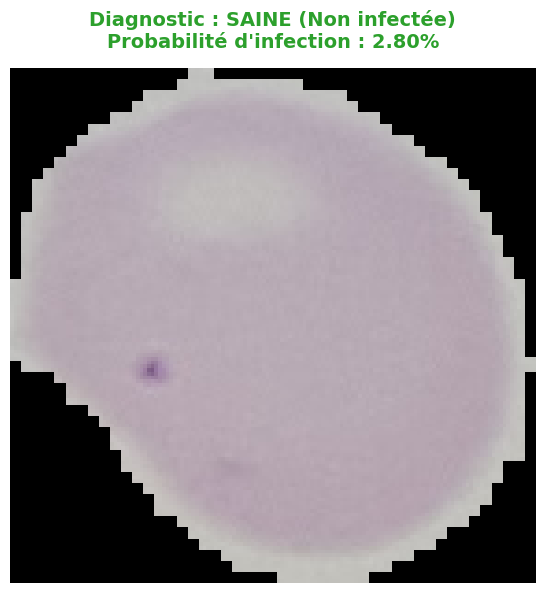

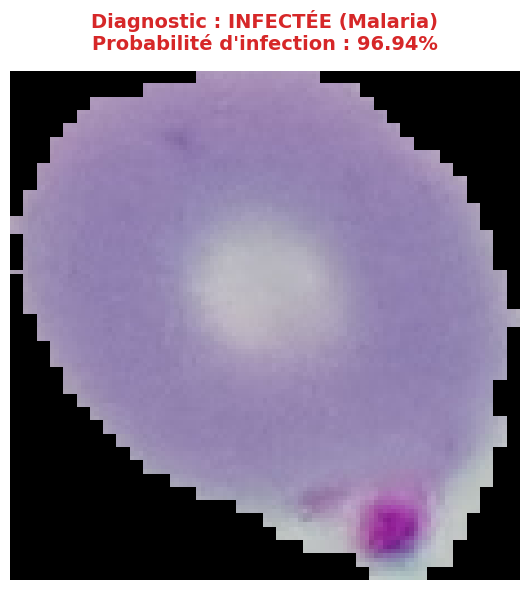

In [3]:
# Diagnostic aléatoire d'une cellule saine
image_saine = random.choice(os.listdir(UNINFECTED_PATH))
path_saine = os.path.join(UNINFECTED_PATH, image_saine)
app.diagnostiquer_une_cellule(path_saine, w_l, b_l, m_l, s_l, p_comp, p_mean)

# Diagnostic aléatoire d'une cellule infectée
image_infectee = random.choice(os.listdir(PARASITIZED_PATH))
path_infectee = os.path.join(PARASITIZED_PATH, image_infectee)
app.diagnostiquer_une_cellule(path_infectee, w_l, b_l, m_l, s_l, p_comp, p_mean)

## Cas d'usage 2 : Le Tri Automatique d'un lot d'images

En laboratoire, il faut parfois trier des dizaines de cellules d'un coup. Nous allons simuler un lot de 10 cellules mélangées et laisser le modèle les trier dans deux dossiers distincts.


Début du tri automatique de 10 images...
Progression : 10/10 images traitées...

--- RAPPORT DE TRI ---
Total analysé : 10
Détectées Saines    : 5 -> copiées dans 'c:\Users\noevm\Documents\INSA_Lyon\3A_2025-2026\S2\UE3_PIML\Projet\Projet_PIML\Data\Temp_Test_Client\Resultats_Saines'
Détectées Infectées : 5 -> copiées dans 'c:\Users\noevm\Documents\INSA_Lyon\3A_2025-2026\S2\UE3_PIML\Projet\Projet_PIML\Data\Temp_Test_Client\Resultats_Infectees'

--- Aperçu des 5 premières images classées 'Saines' ---


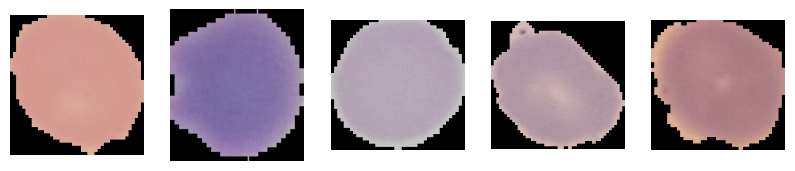


--- Aperçu des 5 premières images classées 'Infectées' ---


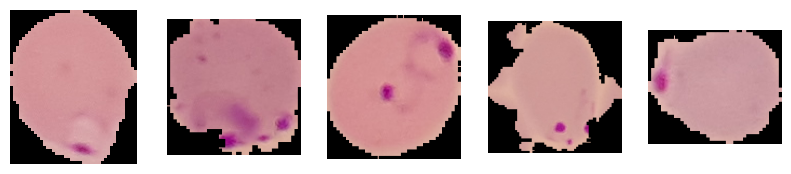

In [4]:
# 1. Préparation du dossier de test temporaire
dossier_demo = os.path.join(PROJET_RACINE, "Data", "Temp_Test_Client")
os.makedirs(dossier_demo, exist_ok=True)

# 2. Copie de 5 images saines et 5 infectées aléatoires
saines_list = random.sample(os.listdir(UNINFECTED_PATH), 5)
infectees_list = random.sample(os.listdir(PARASITIZED_PATH), 5)

for f in saines_list: shutil.copy2(os.path.join(UNINFECTED_PATH, f), os.path.join(dossier_demo, f))
for f in infectees_list: shutil.copy2(os.path.join(PARASITIZED_PATH, f), os.path.join(dossier_demo, f))

# 3. Exécution du tri sur le dossier de test
app.trier_dossier_images(
    dossier_demo, 
    w_l, b_l, m_l, s_l, p_comp, p_mean, 
    afficher_resultats=True
)

In [5]:
shutil.rmtree(dossier_demo)
print("\nNettoyage effectué.")


Nettoyage effectué.
